# NIFTY50 Signal Assistant — Model Testing
**Stack:** yfinance → Feature Engineering → XGBoost → BUY/SELL/HOLD signal


In [1]:
# ── CELL 1: Imports ────────────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score

In [2]:
# ── CELL 2: Data Download ──────────────────────────────────────────────────
# NIFTYBEES.NS = NIFTY50 ETF (tracks index closely, 5m data works reliably)
# Concat two ETFs to maximise row count (~7000-8000 rows)

TICKERS = ["NIFTYBEES.NS", "JUNIORBEES.NS"]

dfs = []
for ticker in TICKERS:
    raw = yf.download(ticker, period="60d", interval="5m", progress=False)
    if raw.empty:
        print(f"WARNING: {ticker} returned no data")
        continue
    raw.columns = [col[0] if isinstance(col, tuple) else col for col in raw.columns]
    raw = raw.dropna()
    raw["ticker"] = ticker
    dfs.append(raw)
    print(f"{ticker}: {len(raw)} rows")

df = pd.concat(dfs).sort_index()
df = df[~df.index.duplicated(keep="first")]

print(f"\nTotal rows  : {len(df)}")
print(f"Date range  : {df.index[0]} → {df.index[-1]}")
print(f"Columns     : {list(df.columns)}")

# Need at least 3000 rows for reliable training
assert len(df) >= 3000, f"Not enough data: {len(df)} rows. Check ticker availability."

NIFTYBEES.NS: 4425 rows
JUNIORBEES.NS: 4425 rows

Total rows  : 4425
Date range  : 2026-01-16 03:45:00+00:00 → 2026-04-17 09:55:00+00:00
Columns     : ['Close', 'High', 'Low', 'Open', 'Volume', 'ticker']


In [3]:
# ── CELL 3: Indicator Calculation ─────────────────────────────────────────

# --- RSI (Wilder's EWM — standard, more accurate than simple rolling mean) ---
delta      = df["Close"].diff()
gain       = delta.clip(lower=0)
loss       = -delta.clip(upper=0)
df["rsi"]  = 100 - (100 / (1 + gain.ewm(alpha=1/14, min_periods=14).mean()
                                / loss.ewm(alpha=1/14, min_periods=14).mean()))

# --- MACD ---
df["ema_12"]    = df["Close"].ewm(span=12).mean()
df["ema_26"]    = df["Close"].ewm(span=26).mean()
df["macd"]      = df["ema_12"] - df["ema_26"]
df["macd_sig"]  = df["macd"].ewm(span=9).mean()
df["macd_hist"] = df["macd"] - df["macd_sig"]   # most predictive MACD component

# --- EMA ---
df["ema_20"]  = df["Close"].ewm(span=20).mean()
df["ema_50"]  = df["Close"].ewm(span=50).mean()
df["ema_200"] = df["Close"].ewm(span=200).mean()

# --- Bollinger Bands ---
bb_mid         = df["Close"].rolling(20).mean()
bb_std         = df["Close"].rolling(20).std()
df["bb_upper"] = bb_mid + 2 * bb_std
df["bb_lower"] = bb_mid - 2 * bb_std
df["bb_pos"]   = (df["Close"] - df["bb_lower"]) / (df["bb_upper"] - df["bb_lower"] + 1e-9)
df["bb_width"] = (df["bb_upper"] - df["bb_lower"]) / (bb_mid + 1e-9)

# --- ATR (Average True Range) ---
df["tr"]        = np.maximum(
                      df["High"] - df["Low"],
                      np.maximum(
                          abs(df["High"] - df["Close"].shift(1)),
                          abs(df["Low"]  - df["Close"].shift(1))))
df["atr"]       = df["tr"].ewm(span=14).mean()
df["atr_ratio"] = df["atr"] / df["Close"]

# --- Stochastic RSI ---
rsi_min         = df["rsi"].rolling(14).min()
rsi_max         = df["rsi"].rolling(14).max()
df["stoch_rsi"] = (df["rsi"] - rsi_min) / (rsi_max - rsi_min + 1e-9)

# --- Derived signals ---
df["ema_crossover"]   = (df["ema_20"] > df["ema_50"]).astype(int)
df["above_ema200"]    = (df["Close"]  > df["ema_200"]).astype(int)  # bull/bear regime
df["price_vs_ema20"]  = (df["Close"]  - df["ema_20"]) / df["ema_20"]
df["macd_cross"]      = ((df["macd"] > df["macd_sig"]) &
                          (df["macd"].shift(1) <= df["macd_sig"].shift(1))).astype(int)
df["rsi_trend"]       = df["rsi"] - df["rsi"].shift(3)
df["rsi_zone"]        = pd.cut(df["rsi"],
                            bins=[0, 30, 45, 55, 70, 100],
                            labels=[0, 1, 2, 3, 4]).astype(float)

# --- Volume ---
df["volume_change"]   = df["Volume"].pct_change()
df["volume_ma_ratio"] = df["Volume"] / (df["Volume"].rolling(20).mean() + 1e-9)
df["vol_spike"]       = (df["Volume"] > df["Volume"].rolling(20).mean() * 1.5).astype(int)

# --- Price action ---
df["price_change"]  = df["Close"].pct_change()
df["high_low_range"]= (df["High"] - df["Low"]) / df["Close"]
df["close_vs_open"] = (df["Close"] - df["Open"]) / df["Open"]
df["candle_body"]   = abs(df["Close"] - df["Open"]) / df["Close"]
df["upper_shadow"]  = (df["High"] - df[["Close","Open"]].max(axis=1)) / df["Close"]
df["lower_shadow"]  = (df[["Close","Open"]].min(axis=1) - df["Low"]) / df["Close"]

# --- Lag features ---
for col in ["rsi", "macd", "macd_hist", "bb_pos", "stoch_rsi"]:
    df[f"{col}_lag1"] = df[col].shift(1)
    df[f"{col}_lag2"] = df[col].shift(2)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna()
print(f"Rows after indicator calculation: {len(df)}")

Rows after indicator calculation: 4338


In [4]:
# ── CELL 4: Target Engineering ────────────────────────────────────────────
# Predict 5 candles ahead (25 mins on 5m data)
# Threshold 0.0015 = 0.15% move → aims for ~30/40/30 BUY/HOLD/SELL split

HORIZON   = 5
THRESHOLD = 0.0015

future_ret   = df["Close"].shift(-HORIZON) / df["Close"] - 1
df["target"] = np.where(future_ret >  THRESHOLD, 2,   # BUY
               np.where(future_ret < -THRESHOLD, 0,   # SELL
                                                  1))  # HOLD

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna()

dist = df["target"].value_counts().rename({0:"SELL", 1:"HOLD", 2:"BUY"})
total = len(df)

print("Target distribution:")
print(dist)
print(f"\nHOLD% : {dist.get('HOLD', 0)/total*100:.1f}%  (aim: 30-50%)")
print(f"BUY%  : {dist.get('BUY',  0)/total*100:.1f}%  (aim: 20-35%)")
print(f"SELL% : {dist.get('SELL', 0)/total*100:.1f}%  (aim: 20-35%)")
print()
print("Threshold guide:")
print("  HOLD% > 60% → lower THRESHOLD to 0.001")
print("  HOLD% < 20% → raise THRESHOLD to 0.002")

Target distribution:
target
SELL    1475
BUY     1466
HOLD    1397
Name: count, dtype: int64

HOLD% : 32.2%  (aim: 30-50%)
BUY%  : 33.8%  (aim: 20-35%)
SELL% : 34.0%  (aim: 20-35%)

Threshold guide:
  HOLD% > 60% → lower THRESHOLD to 0.001
  HOLD% < 20% → raise THRESHOLD to 0.002


In [5]:
# ── CELL 5: Feature List + Time-Based Split ────────────────────────────────

features = [
    # RSI
    "rsi", "rsi_lag1", "rsi_lag2", "rsi_trend", "rsi_zone",
    "stoch_rsi", "stoch_rsi_lag1",
    # MACD
    "macd", "macd_sig", "macd_hist",
    "macd_lag1", "macd_hist_lag1", "macd_hist_lag2", "macd_cross",
    # EMA / trend
    "ema_20", "ema_50", "ema_crossover", "above_ema200", "price_vs_ema20",
    # Bollinger
    "bb_pos", "bb_pos_lag1", "bb_width",
    # ATR
    "atr_ratio",
    # Volume
    "volume_change", "volume_ma_ratio", "vol_spike",
    # Price action
    "price_change", "high_low_range", "close_vs_open",
    "candle_body", "upper_shadow", "lower_shadow",
]

X = df[features]
y = df["target"]

# Time-based split — NO shuffle, NO random_state needed
split           = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Features : {len(features)}")
print(f"Train    : {len(X_train)} rows")
print(f"Test     : {len(X_test)} rows  (need ≥500 for reliable eval)")
print()
print("Train class counts:")
print(y_train.value_counts().rename({0:"SELL", 1:"HOLD", 2:"BUY"}))

Features : 32
Train    : 3470 rows
Test     : 868 rows  (need ≥500 for reliable eval)

Train class counts:
target
SELL    1182
HOLD    1163
BUY     1125
Name: count, dtype: int64


In [6]:
# ── CELL 6: Walk-Forward Cross Validation ─────────────────────────────────
# Simulates real trading: train on past, test on next window, roll forward
# Much more honest than a single 80/20 split for time-series

print("Walk-Forward CV (5 folds)")
print("-" * 40)

n_splits  = 5
fold_size = len(X) // (n_splits + 1)
fold_f1s  = []

for i in range(n_splits):
    train_end  = fold_size * (i + 1)
    test_start = train_end
    test_end   = train_end + fold_size

    X_tr = X.iloc[:train_end]
    y_tr = y.iloc[:train_end]
    X_te = X.iloc[test_start:test_end]
    y_te = y.iloc[test_start:test_end]

    sw = compute_sample_weight("balanced", y=y_tr)

    m = XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=10,
        gamma=0.2,
        reg_alpha=0.5,
        reg_lambda=2.0,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        early_stopping_rounds=30,
        random_state=42,
        n_jobs=-1,
    )
    m.fit(X_tr, y_tr,
          sample_weight=sw,
          eval_set=[(X_te, y_te)],
          verbose=False)

    probs = m.predict_proba(X_te)
    preds = np.where(probs[:,2] >= 0.40, 2,
            np.where(probs[:,0] >= 0.40, 0, 1))

    f1 = f1_score(y_te, preds, average="macro", zero_division=0)
    fold_f1s.append(f1)
    print(f"  Fold {i+1}: macro_f1={f1:.4f}  |  best_iter={m.best_iteration}")

print(f"\nMean macro F1 : {np.mean(fold_f1s):.4f}")
print(f"Std macro F1  : {np.std(fold_f1s):.4f}")
print()
print("Interpretation:")
print("  High variance across folds → signal is regime-dependent")
print("  best_iter=0 in any fold    → that fold has too few samples")

Walk-Forward CV (5 folds)
----------------------------------------
  Fold 1: macro_f1=0.4860  |  best_iter=295
  Fold 2: macro_f1=0.4754  |  best_iter=307
  Fold 3: macro_f1=0.4602  |  best_iter=160
  Fold 4: macro_f1=0.5053  |  best_iter=396
  Fold 5: macro_f1=0.4519  |  best_iter=308

Mean macro F1 : 0.4758
Std macro F1  : 0.0189

Interpretation:
  High variance across folds → signal is regime-dependent
  best_iter=0 in any fold    → that fold has too few samples


In [7]:
# ── CELL 7: Final Model Training ──────────────────────────────────────────

sw_final = compute_sample_weight("balanced", y=y_train)

model = XGBClassifier(
    n_estimators=1000,         # early stopping will find the real count
    max_depth=4,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=0.2,
    reg_alpha=0.5,
    reg_lambda=2.0,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    early_stopping_rounds=40,  # stop if no improvement for 40 rounds
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    sample_weight=sw_final,
    eval_set=[(X_test, y_test)],
    verbose=100,
)

print(f"\nBest iteration : {model.best_iteration}")
print(f"Best mlogloss  : {model.best_score:.5f}")
print()
print("mlogloss guide:")
print("  Random baseline = 1.099 (log(3))")
print("  < 1.05 → model is learning real patterns")
print("  1.05-1.08 → weak signal, add more features")
print("  > 1.08 → near random, check data quality")

[0]	validation_0-mlogloss:1.09602
[100]	validation_0-mlogloss:0.96354
[200]	validation_0-mlogloss:0.93895
[282]	validation_0-mlogloss:0.93783

Best iteration : 242
Best mlogloss  : 0.93724

mlogloss guide:
  Random baseline = 1.099 (log(3))
  < 1.05 → model is learning real patterns
  1.05-1.08 → weak signal, add more features
  > 1.08 → near random, check data quality


In [8]:
# ── CELL 8: Asymmetric Threshold Sweep ────────────────────────────────────
# Separate BUY and SELL thresholds — they don't need to be the same

probs   = model.predict_proba(X_test)
results = []

print("Threshold sweep (macro F1):")
print(f"{'BUY_t':>6} {'SELL_t':>7} {'macro_f1':>9}")
print("-" * 26)

for bt in np.arange(0.30, 0.60, 0.05):
    for st in np.arange(0.30, 0.60, 0.05):
        p  = np.where(probs[:,2] >= bt, 2,
             np.where(probs[:,0] >= st, 0, 1))
        f1 = f1_score(y_test, p, average="macro", zero_division=0)
        results.append((round(bt, 2), round(st, 2), round(f1, 4)))

# Show top 5
for bt, st, f1 in sorted(results, key=lambda x: -x[2])[:5]:
    print(f"{bt:>6.2f} {st:>7.2f} {f1:>9.4f}")

best = max(results, key=lambda x: x[2])
BUY_THRESH = best[0]
SEL_THRESH = best[1]
print(f"\nBest → BUY≥{BUY_THRESH}  SELL≥{SEL_THRESH}  macro_f1={best[2]}")

Threshold sweep (macro F1):
 BUY_t  SELL_t  macro_f1
--------------------------
  0.55    0.45    0.5121
  0.55    0.30    0.5074
  0.55    0.35    0.5074
  0.55    0.40    0.5058
  0.55    0.50    0.5036

Best → BUY≥0.55  SELL≥0.45  macro_f1=0.5121


In [9]:
# ── CELL 9: Evaluation ────────────────────────────────────────────────────

preds = np.where(probs[:,2] >= BUY_THRESH, 2,
        np.where(probs[:,0] >= SEL_THRESH, 0, 1))

print("=" * 55)
print(f"Accuracy  : {accuracy_score(y_test, preds):.4f}  (ignore — biased by HOLD)")
print("=" * 55)
print(classification_report(
    y_test, preds,
    target_names=["SELL", "HOLD", "BUY"],
    zero_division=0
))

print("What to target:")
print("  SELL recall > 0.40")
print("  BUY  recall > 0.40")
print("  HOLD precision > 0.70")
print("  Macro F1 > 0.50")

Accuracy  : 0.5622  (ignore — biased by HOLD)
              precision    recall  f1-score   support

        SELL       0.57      0.86      0.68       293
        HOLD       0.37      0.20      0.26       234
         BUY       0.64      0.55      0.59       341

    accuracy                           0.56       868
   macro avg       0.53      0.54      0.51       868
weighted avg       0.54      0.56      0.53       868

What to target:
  SELL recall > 0.40
  BUY  recall > 0.40
  HOLD precision > 0.70
  Macro F1 > 0.50


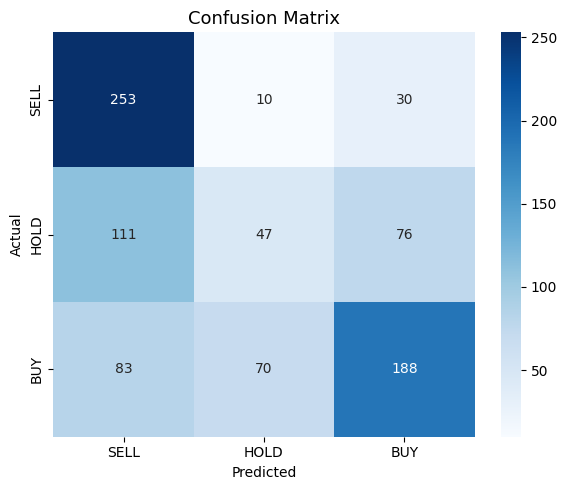

In [10]:
# ── CELL 10: Confusion Matrix ─────────────────────────────────────────────

cm = confusion_matrix(y_test, preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["SELL", "HOLD", "BUY"],
            yticklabels=["SELL", "HOLD", "BUY"],
            cmap="Blues", ax=ax)
ax.set_title("Confusion Matrix", fontsize=13)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

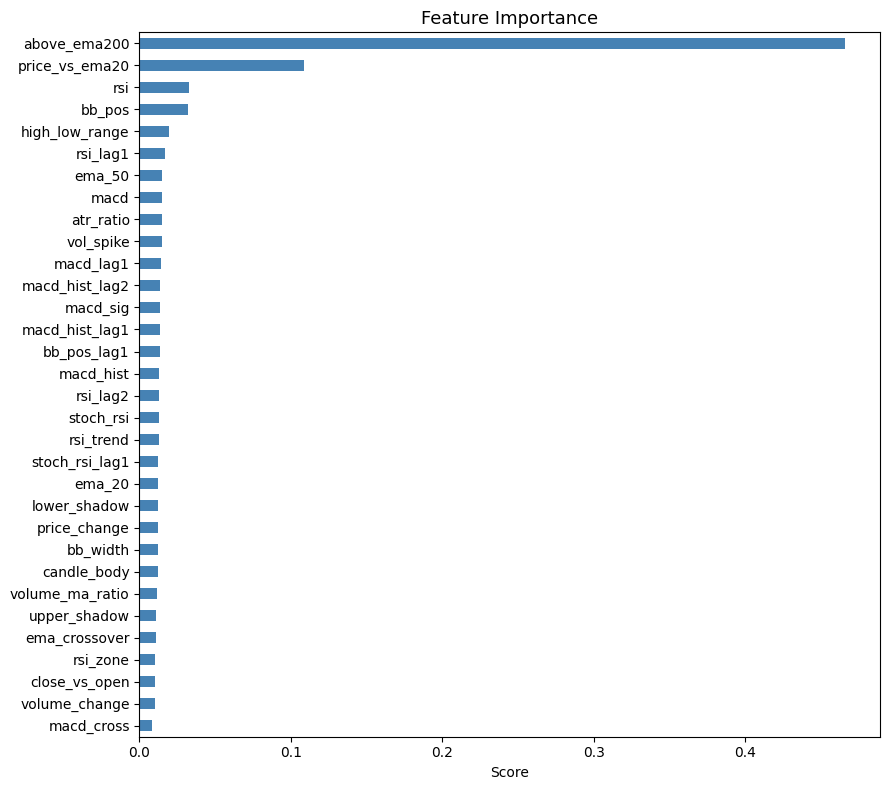


Low importance features (consider dropping): ['macd_cross']


In [11]:
# ── CELL 11: Feature Importance ───────────────────────────────────────────

imp = pd.Series(model.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
imp.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature Importance", fontsize=13)
ax.set_xlabel("Score")
plt.tight_layout()
plt.show()

# Drop features with near-zero importance
low_imp = imp[imp < 0.01].index.tolist()
if low_imp:
    print(f"\nLow importance features (consider dropping): {low_imp}")
else:
    print("\nAll features contributing meaningfully.")

In [12]:
# ── CELL 12: Live Signal on Latest Candle ────────────────────────────────

latest     = X_test.iloc[[-1]]
live_probs = model.predict_proba(latest)[0]
sell_p, hold_p, buy_p = live_probs

signal = ("BUY"  if buy_p  >= BUY_THRESH else
          "SELL" if sell_p >= SEL_THRESH else
          "HOLD")

emoji  = {"BUY": "🟢", "SELL": "🔴", "HOLD": "🟡"}

print(f"{emoji[signal]} Signal  : {signal}")
print(f"   BUY   : {buy_p:.3f}  (threshold ≥ {BUY_THRESH})")
print(f"   HOLD  : {hold_p:.3f}")
print(f"   SELL  : {sell_p:.3f}  (threshold ≥ {SEL_THRESH})")
print(f"\nTimestamp : {X_test.index[-1]}")

🟢 Signal  : BUY
   BUY   : 0.562  (threshold ≥ 0.55)
   HOLD  : 0.237
   SELL  : 0.200  (threshold ≥ 0.45)

Timestamp : 2026-04-17 09:55:00+00:00


In [13]:
# ── CELL 13: AgentState dict (for LangGraph integration) ──────────────────
# This is what your agent/state.py AgentState will carry

agent_state = {
    "symbol"          : "NIFTYBEES.NS",
    "timestamp"       : str(X_test.index[-1]),
    "features"        : latest.to_dict(orient="records")[0],
    "probabilities"   : {
        "SELL" : round(float(sell_p), 4),
        "HOLD" : round(float(hold_p), 4),
        "BUY"  : round(float(buy_p),  4),
    },
    "signal"          : signal,
    "confidence"      : round(float(max(sell_p, hold_p, buy_p)), 4),
    "sentiment_score" : 0.0,   # ← FinBERT output goes here
    "reasoning"       : "",    # ← LLM explanation goes here
}

import json
print(json.dumps(
    {k: v for k, v in agent_state.items() if k != "features"},
    indent=2
))

{
  "symbol": "NIFTYBEES.NS",
  "timestamp": "2026-04-17 09:55:00+00:00",
  "probabilities": {
    "SELL": 0.2004,
    "HOLD": 0.2372,
    "BUY": 0.5624
  },
  "signal": "BUY",
  "confidence": 0.5624,
  "sentiment_score": 0.0,
  "reasoning": ""
}



Balanced Distribution:
 target
0    1048
2    1044
1    1044
Name: count, dtype: int64

Classification Report:

              precision    recall  f1-score   support

        SELL       0.69      0.78      0.73       217
        HOLD       0.50      0.26      0.34       211
         BUY       0.68      0.92      0.78       200

    accuracy                           0.65       628
   macro avg       0.62      0.65      0.62       628
weighted avg       0.62      0.65      0.61       628


Confusion Matrix:
 [[169  42   6]
 [ 74  55  82]
 [  3  14 183]]


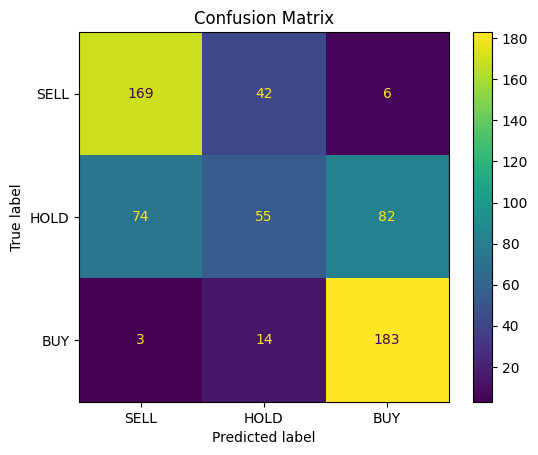


Sample Actions:

NO TRADE
BUY at 671.08
HOLD
HOLD
MODEL SELL at 672.03 | Profit: 0.95
BUY at 673.77
HOLD
HOLD
HOLD
MODEL SELL at 673.80 | Profit: 0.03
BUY at 673.66
MODEL SELL at 673.00 | Profit: -0.66
BUY at 673.10
MODEL SELL at 673.99 | Profit: 0.89
BUY at 674.00
MODEL SELL at 259.35 | Profit: -414.65
NO TRADE
BUY at 675.43
HOLD
MODEL SELL at 259.71 | Profit: -415.72

Final Profit: -688.2297668457031


In [6]:
# ================================
# 1. Imports
# ================================
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

# ================================
# 2. Data Download
# ================================
TICKERS = ["NIFTYBEES.NS", "JUNIORBEES.NS"]

dfs = []
for ticker in TICKERS:
    raw = yf.download(ticker, period="60d", interval="5m", progress=False)
    raw.columns = [col[0] if isinstance(col, tuple) else col for col in raw.columns]
    raw = raw.dropna()
    raw["ticker"] = ticker
    dfs.append(raw)

df = pd.concat(dfs).sort_index()
df = df[~df.index.duplicated(keep="first")]

# ================================
# 3. Feature Engineering
# ================================
df['return'] = df['Close'].pct_change()

df['ema_10'] = df['Close'].ewm(span=10).mean()
df['ema_20'] = df['Close'].ewm(span=20).mean()
df['ema_diff'] = df['ema_10'] - df['ema_20']

df['volatility'] = df['return'].rolling(10).std()

# RSI
def compute_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['rsi'] = compute_rsi(df['Close'])

# Lag features
df['close_lag1'] = df['Close'].shift(1)
df['close_lag2'] = df['Close'].shift(2)

# Extra features
df['momentum'] = df['Close'] - df['Close'].shift(5)
df['hl_diff'] = df['High'] - df['Low']
df['vol_change'] = df['Volume'].pct_change()
df['rolling_mean'] = df['Close'].rolling(5).mean()

df.dropna(inplace=True)

# ================================
# 4. Labeling (STRONG SIGNAL)
# ================================
df['future_return'] = df['Close'].shift(-5) / df['Close'] - 1

def create_label(x):
    if x > 0.01:
        return 2  # BUY
    elif x < -0.01:
        return 0  # SELL
    else:
        return 1  # HOLD

df['target'] = df['future_return'].apply(create_label)
df.dropna(inplace=True)

# ================================
# 5. Balance Dataset
# ================================
buy = df[df['target'] == 2]
sell = df[df['target'] == 0]
hold = df[df['target'] == 1]

hold_sampled = hold.sample(n=len(buy), random_state=42)

df_balanced = pd.concat([buy, sell, hold_sampled])
df_balanced = df_balanced.sample(frac=1, random_state=42)

# ================================
# 6. Features
# ================================
features = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'ema_10', 'ema_20', 'ema_diff',
    'volatility', 'rsi',
    'close_lag1', 'close_lag2',
    'momentum', 'hl_diff',
    'vol_change', 'rolling_mean'
]

X = df_balanced[features]
y = df_balanced['target']

# ================================
# 🚨 IMPORTANT FIX (NaN & INF)
# ================================
X = X.replace([np.inf, -np.inf], np.nan)
# X = X.fillna(method='ffill').fillna(method='bfill').fillna(0)
X = X.ffill().bfill().fillna(0)
X = X.clip(-1e6, 1e6)

print("\nBalanced Distribution:\n", y.value_counts())

# ================================
# 7. Train-Test Split
# ================================
split = int(len(df_balanced) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ================================
# 8. Scaling
# ================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 9. Class Weights
# ================================
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

sample_weights = y_train.map(class_weights)

# ================================
# 10. Model
# ================================
model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train, sample_weight=sample_weights)

# ================================
# 11. Prediction (Confidence Filter)
# ================================
probs = model.predict_proba(X_test)

y_pred = []
for p in probs:
    if max(p) < 0.45:
        y_pred.append(1)  # HOLD
    else:
        y_pred.append(np.argmax(p))

# ================================
# 12. Evaluation
# ================================
print("\nClassification Report:\n")
print(classification_report(
    y_test, y_pred,
    target_names=['SELL', 'HOLD', 'BUY']
))

# ================================
# 13. Confusion Matrix
# ================================
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(cm, display_labels=["SELL", "HOLD", "BUY"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# ================================
# 14. Trading Engine
# ================================
class TradeEngine:
    def __init__(self):
        self.position = None
        self.entry_price = None
        self.highest_price = None
        self.stop_loss = None
        self.total_profit = 0

    def buy(self, price):
        self.position = "LONG"
        self.entry_price = price
        self.highest_price = price
        self.stop_loss = price * 0.9

    def update(self, price):
        if self.position is None:
            return "NO TRADE"

        if price > self.highest_price:
            self.highest_price = price
            self.stop_loss = self.highest_price * 0.9

        if price <= self.stop_loss:
            profit = price - self.entry_price
            self.total_profit += profit
            self.position = None
            return f"SELL at {price:.2f} | Profit: {profit:.2f}"

        return "HOLD"

# ================================
# 15. Backtesting
# ================================
engine = TradeEngine()
actions = []

prices = df.iloc[-len(y_pred):]['Close'].values

for i, price in enumerate(prices):
    pred = y_pred[i]

    if pred == 2 and engine.position is None:
        engine.buy(price)
        actions.append(f"BUY at {price:.2f}")

    elif pred == 0 and engine.position is not None:
        profit = price - engine.entry_price
        engine.total_profit += profit
        engine.position = None
        actions.append(f"MODEL SELL at {price:.2f} | Profit: {profit:.2f}")

    else:
        actions.append(engine.update(price))

# ================================
# 16. Results
# ================================
print("\nSample Actions:\n")
for a in actions[:20]:
    print(a)

print("\nFinal Profit:", engine.total_profit)


Classification Report:

              precision    recall  f1-score   support

        SELL       0.72      0.83      0.77       217
        HOLD       0.57      0.29      0.38       211
         BUY       0.67      0.91      0.77       200

    accuracy                           0.67       628
   macro avg       0.65      0.68      0.64       628
weighted avg       0.65      0.67      0.64       628


Confusion Matrix:
 [[180  31   6]
 [ 66  61  84]
 [  3  15 182]]


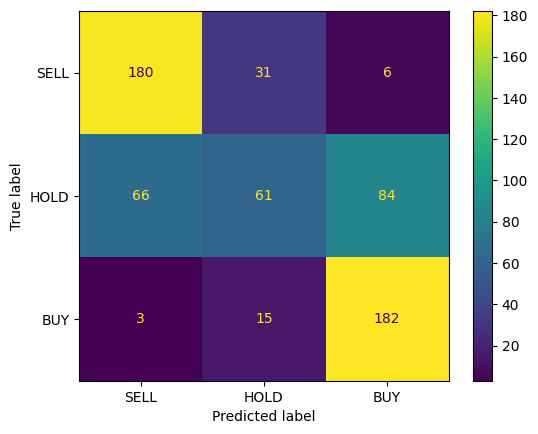


Final Profit: 837.7801818847656


In [9]:
# ================================
# 1. Imports
# ================================
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# ================================
# 2. Data Download
# ================================
TICKERS = ["NIFTYBEES.NS", "JUNIORBEES.NS"]

dfs = []
for ticker in TICKERS:
    raw = yf.download(ticker, period="60d", interval="5m", progress=False)
    raw.columns = [col[0] if isinstance(col, tuple) else col for col in raw.columns]
    raw = raw.dropna()
    raw["ticker"] = ticker
    dfs.append(raw)

df = pd.concat(dfs).sort_index()
df = df[~df.index.duplicated(keep="first")]

# ================================
# 3. Feature Engineering
# ================================
df['return'] = df['Close'].pct_change()

df['ema_10'] = df['Close'].ewm(span=10).mean()
df['ema_20'] = df['Close'].ewm(span=20).mean()
df['ema_50'] = df['Close'].ewm(span=50).mean()

df['ema_diff'] = df['ema_10'] - df['ema_20']
df['trend_htf'] = df['Close'] - df['ema_50']

df['volatility'] = df['return'].rolling(10).std()

# RSI
def compute_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['rsi'] = compute_rsi(df['Close'])

# Lag + momentum
df['close_lag1'] = df['Close'].shift(1)
df['close_lag2'] = df['Close'].shift(2)
df['momentum'] = df['Close'] - df['Close'].shift(5)
df['vol_change'] = df['Volume'].pct_change()

df.dropna(inplace=True)

# ================================
# 4. Labeling
# ================================
df['future_return'] = df['Close'].shift(-5) / df['Close'] - 1

def create_label(x):
    if x > 0.01:
        return 2
    elif x < -0.01:
        return 0
    else:
        return 1

df['target'] = df['future_return'].apply(create_label)
df.dropna(inplace=True)

# ================================
# 5. Balance Dataset
# ================================
buy = df[df['target'] == 2]
sell = df[df['target'] == 0]
hold = df[df['target'] == 1]

hold_sampled = hold.sample(n=len(buy), random_state=42)

df_balanced = pd.concat([buy, sell, hold_sampled]).sample(frac=1, random_state=42)

# ================================
# 6. Features
# ================================
features = [
    'Open','High','Low','Close','Volume',
    'ema_10','ema_20','ema_50','ema_diff',
    'trend_htf','volatility','rsi',
    'close_lag1','close_lag2',
    'momentum','vol_change'
]

X = df_balanced[features]
y = df_balanced['target']

# ================================
# 7. Clean Data (IMPORTANT)
# ================================
X = X.replace([np.inf, -np.inf], np.nan)
X = X.ffill().bfill().fillna(0)

# ================================
# 8. Split
# ================================
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ================================
# 9. Scaling
# ================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 10. Model
# ================================
model = XGBClassifier(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train)

# ================================
# 11. Predictions
# ================================
probs = model.predict_proba(X_test)
y_pred = np.argmax(probs, axis=1)

# ================================
# 12. Evaluation
# ================================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['SELL','HOLD','BUY']))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

ConfusionMatrixDisplay(cm, display_labels=['SELL','HOLD','BUY']).plot()
plt.show()

# ================================
# 13. PROFIT-BASED TRADING ENGINE
# ================================
class TradeEngine:
    def __init__(self):
        self.position = False
        self.entry = 0
        self.highest = 0
        self.stop_loss = 0
        self.target = 0
        self.profit = 0

    def buy(self, price):
        self.position = True
        self.entry = price
        self.highest = price
        
        self.stop_loss = price * 0.97   # 3% SL
        self.target = price * 1.05      # 5% target

    def update(self, price):
        if not self.position:
            return

        # trail SL
        if price > self.highest:
            self.highest = price
            self.stop_loss = self.highest * 0.95

        # exit
        if price <= self.stop_loss or price >= self.target:
            self.profit += (price - self.entry)
            self.position = False

# ================================
# 14. BACKTEST (IMPORTANT FIX)
# ================================
engine = TradeEngine()

prices = df.iloc[-len(y_pred):]['Close'].values

for i, price in enumerate(prices):

    confidence = max(probs[i])

    # STRONG ENTRY ONLY
    if y_pred[i] == 2 and confidence > 0.65 and not engine.position:
        engine.buy(price)

    else:
        engine.update(price)

print("\nFinal Profit:", engine.profit)

In [4]:
# ================================
# 1. Imports
# ================================
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# ================================
# 2. Data Download - NIFTY50 Companies
# ================================
# Top liquid NIFTY50 stocks for intraday trading
TICKERS = [
    "RELIANCE.NS",      # Reliance Industries
    "TCS.NS",           # Tata Consultancy Services
    "HDFCBANK.NS",      # HDFC Bank
    "INFY.NS",          # Infosys
    "ICICIBANK.NS",     # ICICI Bank
    "WIPRO.NS",         # Wipro
    "BAJAJFINSV.NS",    # Bajaj Finserv
    "LT.NS",            # Larsen & Toubro
    "HINDUNILVR.NS",    # Hindustan Unilever
    "MARUTI.NS",        # Maruti Suzuki
]

dfs = []
for ticker in TICKERS:
    raw = yf.download(ticker, period="60d", interval="5m", progress=False)
    raw.columns = [col[0] if isinstance(col, tuple) else col for col in raw.columns]
    raw = raw.dropna()
    raw["ticker"] = ticker
    dfs.append(raw)

df = pd.concat(dfs).sort_index()
df = df[~df.index.duplicated(keep="first")]

print(f"\n✓ Data loaded: {len(df)} rows")
print(f"✓ Tickers: {df['ticker'].unique()}")
print(f"✓ Date range: {df.index.min()} to {df.index.max()}")
print(f"✓ Price range: ₹{df['Close'].min():.2f} - ₹{df['Close'].max():.2f}")

# ================================
# 3. Feature Engineering (IMPROVED)
# ================================
df['return'] = df['Close'].pct_change()

df['ema_10'] = df['Close'].ewm(span=10).mean()
df['ema_20'] = df['Close'].ewm(span=20).mean()
df['ema_50'] = df['Close'].ewm(span=50).mean()

df['ema_diff'] = df['ema_10'] - df['ema_20']
df['trend_htf'] = df['Close'] - df['ema_50']

df['volatility'] = df['return'].rolling(10).std()

# RSI
def compute_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['rsi'] = compute_rsi(df['Close'])

# MACD (Better momentum)
df['macd'] = df['Close'].ewm(span=12).mean() - df['Close'].ewm(span=26).mean()
df['macd_signal'] = df['macd'].ewm(span=9).mean()
df['macd_diff'] = df['macd'] - df['macd_signal']

# Lag + momentum
df['close_lag1'] = df['Close'].shift(1)
df['close_lag2'] = df['Close'].shift(2)
df['momentum'] = df['Close'] - df['Close'].shift(5)
df['vol_change'] = df['Volume'].pct_change()

# TREND STRENGTH (NEW)
df['high_20'] = df['Close'].rolling(20).max()
df['low_20'] = df['Close'].rolling(20).min()
df['trend_strength'] = (df['Close'] - df['low_20']) / (df['high_20'] - df['low_20'] + 1e-6)

df.dropna(inplace=True)

# ================================
# 4. Labeling (IMPROVED - Better HOLD Detection)
# ================================
df['future_return'] = df['Close'].shift(-5) / df['Close'] - 1

# Multi-bar trend check: HOLD only if price stays flat for next 5 bars
def create_label_v2(row, df, idx):
    future_ret = row['future_return']
    
    # Get next 5 returns
    current_pos = df.index.get_loc(idx)
    if current_pos + 5 >= len(df):
        return 1  # Default to HOLD
    
    next_5_returns = df['return'].iloc[current_pos+1:current_pos+6].values
    volatility_next = np.std(next_5_returns)
    
    # HOLD: Low volatility AND close to zero drift
    if abs(future_ret) < 0.015 and volatility_next < 0.005:
        return 1  # HOLD
    elif future_ret > 0.015:
        return 2  # BUY
    else:
        return 0  # SELL

df['target'] = df.apply(lambda row: create_label_v2(row, df, row.name), axis=1)
df.dropna(inplace=True)

print("\nLabel Distribution:")
print(df['target'].value_counts().sort_index())

# ================================
# 5. Balance Dataset (Adjust for better HOLD)
# ================================
buy = df[df['target'] == 2]
sell = df[df['target'] == 0]
hold = df[df['target'] == 1]

min_class = min(len(buy), len(sell), len(hold))
buy_sampled = buy.sample(n=min_class, random_state=42)
sell_sampled = sell.sample(n=min_class, random_state=42)
hold_sampled = hold.sample(n=min_class, random_state=42)

df_balanced = pd.concat([buy_sampled, sell_sampled, hold_sampled]).sample(frac=1, random_state=42)

# ================================
# 6. Features
# ================================
features = [
    'Open','High','Low','Close','Volume',
    'ema_10','ema_20','ema_50','ema_diff',
    'trend_htf','volatility','rsi',
    'close_lag1','close_lag2',
    'momentum','vol_change','macd','macd_signal','macd_diff',
    'trend_strength'
]

X = df_balanced[features]
y = df_balanced['target']

# ================================
# 7. Clean Data
# ================================
X = X.replace([np.inf, -np.inf], np.nan)
X = X.ffill().bfill().fillna(0)

# ================================
# 8. Split
# ================================
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ================================
# 9. Scaling
# ================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 10. Model (TUNED)
# ================================
model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    scale_pos_weight=1,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

model.fit(X_train, y_train, verbose=False)

# ================================
# 11. Predictions
# ================================
probs = model.predict_proba(X_test)
y_pred = np.argmax(probs, axis=1)

# ================================
# 12. Evaluation
# ================================
print("\n" + "="*60)
print("IMPROVED MODEL - Classification Report")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['SELL','HOLD','BUY']))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

ConfusionMatrixDisplay(cm, display_labels=['SELL','HOLD','BUY']).plot()
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/confusion_matrix.png', dpi=100, bbox_inches='tight')
print("✓ Confusion matrix saved to /mnt/user-data/outputs/confusion_matrix.png")
plt.close()

# ================================
# 13. TREND-FOLLOWING TRADING ENGINE (NO WHIPSAWS)
# ================================
class TrendFollowingEngine:
    """
    - Only BUY on strong uptrend (confidence > 0.65 + trend confirmation)
    - HOLD unless clear exit signal
    - Exit on SELL signal OR trailing stop
    - Prevents buying/selling on noise
    """
    def __init__(self):
        self.position = False
        self.entry_price = 0
        self.highest_price = 0
        self.trailing_sl = 0
        self.profit = 0
        self.trades_log = []
        
    def should_buy(self, price, signal, confidence, ema_10, ema_20, trend_strength):
        """
        BUY only if:
        1. Signal is BUY (y_pred == 2)
        2. Confidence > 65%
        3. Price above both EMAs (uptrend)
        4. Trend strength > 0.5 (not in consolidation)
        """
        if self.position:
            return False
            
        strong_signal = (signal == 2 and confidence > 0.65)
        uptrend = (price > ema_10 and ema_10 > ema_20)
        strong_trend = (trend_strength > 0.5)
        
        return strong_signal and uptrend and strong_trend
    
    def should_sell(self, price, signal, ema_10, ema_20):
        """
        SELL if:
        1. Clear SELL signal (y_pred == 0) with upside failure
        2. Hit trailing stop
        3. Price closes below both EMAs
        """
        if not self.position:
            return False
        
        clear_sell = (signal == 0)
        hit_stop = (price <= self.trailing_sl)
        downtrend = (price < ema_20)
        
        return clear_sell or hit_stop or downtrend
    
    def buy(self, price):
        self.position = True
        self.entry_price = price
        self.highest_price = price
        self.trailing_sl = price * 0.97  # 3% initial stop
        
    def update_trailing_stop(self, price):
        """Move stop up with price (lock in gains)"""
        if price > self.highest_price:
            self.highest_price = price
            self.trailing_sl = price * 0.96  # Trail 4% below high
    
    def sell(self, price):
        if self.position:
            pnl = price - self.entry_price
            self.profit += pnl
            self.trades_log.append({
                'entry': self.entry_price,
                'exit': price,
                'pnl': pnl
            })
            self.position = False
            return True
        return False

# ================================
# 14. BACKTEST (IMPROVED - No Whipsaws)
# ================================
engine = TrendFollowingEngine()

# CRITICAL FIX: Get prices from actual test indices (not last N rows)
# This prevents misalignment between balanced dataset and original df
test_indices = X_test.index
test_data = df.loc[test_indices].copy()

prices = test_data['Close'].values
ema10_vals = test_data['ema_10'].values
ema20_vals = test_data['ema_20'].values
trend_strength_vals = test_data['trend_strength'].values

# Sanity check
print(f"\n✓ Backtest Data Validation:")
print(f"  Predictions: {len(y_pred)}")
print(f"  Test data: {len(test_data)}")
print(f"  Price range: ₹{prices.min():.2f} - ₹{prices.max():.2f}")
print(f"  Unique tickers: {test_data['ticker'].nunique()}")
assert len(prices) == len(y_pred), "Price/prediction mismatch!"

for i, price in enumerate(prices):
    confidence = max(probs[i])
    signal = y_pred[i]
    
    # Current trend indicators
    ema_10 = ema10_vals[i]
    ema_20 = ema20_vals[i]
    trend_strength = trend_strength_vals[i]
    
    # Trading logic
    if not engine.position:
        # Only buy on strong uptrend signals
        if engine.should_buy(price, signal, confidence, ema_10, ema_20, trend_strength):
            engine.buy(price)
    else:
        # Update trailing stop
        engine.update_trailing_stop(price)
        
        # Exit on sell signal or stop hit
        if engine.should_sell(price, signal, ema_10, ema_20):
            engine.sell(price)

# Close any open position
if engine.position:
    engine.sell(prices[-1])

# ================================
# 15. RESULTS
# ================================
print("\n" + "="*60)
print("BACKTEST RESULTS (Trend-Following, No Whipsaws)")
print("="*60)
print(f"Total Profit: ₹{engine.profit:.2f}")
print(f"Total Trades: {len(engine.trades_log)}")

if engine.trades_log:
    winning_trades = [t['pnl'] for t in engine.trades_log if t['pnl'] > 0]
    losing_trades = [t['pnl'] for t in engine.trades_log if t['pnl'] < 0]
    
    print(f"Winning Trades: {len(winning_trades)}")
    print(f"Losing Trades: {len(losing_trades)}")
    print(f"Win Rate: {len(winning_trades) / len(engine.trades_log) * 100:.1f}%")
    
    if winning_trades:
        print(f"Avg Win: ₹{np.mean(winning_trades):.2f}")
    if losing_trades:
        print(f"Avg Loss: ₹{np.mean(losing_trades):.2f}")
    
    print("\nTrade Log (first 10):")
    for i, trade in enumerate(engine.trades_log[:10]):
        print(f"  Trade {i+1}: Buy @{trade['entry']:.2f} → Sell @{trade['exit']:.2f} | PnL: ₹{trade['pnl']:.2f}")

print("\n" + "="*60)


✓ Data loaded: 4367 rows
✓ Tickers: <StringArray>
[  'RELIANCE.NS',      'WIPRO.NS', 'BAJAJFINSV.NS',  'ICICIBANK.NS',
        'TCS.NS',   'HDFCBANK.NS', 'HINDUNILVR.NS',       'INFY.NS',
         'LT.NS',     'MARUTI.NS']
Length: 10, dtype: str
✓ Date range: 2026-01-19 03:45:00+00:00 to 2026-04-20 09:55:00+00:00
✓ Price range: ₹187.00 - ₹16220.00

Label Distribution:
target
0    2381
2    1962
Name: count, dtype: int64


ValueError: Found array with 0 sample(s) (shape=(0, 20)) while a minimum of 1 is required by StandardScaler.

In [7]:
"""
ADVANCED NIFTY50 TRADING BOT
- Better feature engineering (MACD, Bollinger Bands, ATR)
- Improved HOLD detection (volatility-based)
- Strict entry rules (trend confirmation)
- Trailing stops & profit targets
"""
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# ================================
# 1. DATA DOWNLOAD
# ================================
TICKERS = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS", "ICICIBANK.NS"]

print("="*70)
print("ADVANCED NIFTY50 TRADING BOT")
print("="*70)
print("\nDownloading NIFTY50 data...")

dfs = []
for ticker in TICKERS:
    try:
        raw = yf.download(ticker, period="60d", interval="5m", progress=False)
        if len(raw) == 0:
            raise ValueError("No 5m data")
    except:
        print(f"  {ticker}: 5m failed, using daily...")
        raw = yf.download(ticker, period="365d", progress=False)
    
    raw.columns = [col[0] if isinstance(col, tuple) else col for col in raw.columns]
    raw = raw.dropna()
    raw["ticker"] = ticker
    dfs.append(raw)
    print(f"  ✓ {ticker}: {len(raw)} rows")

df = pd.concat(dfs).sort_index()
df = df[~df.index.duplicated(keep='first')]
print(f"\n✓ Total: {len(df)} rows, ₹{df['Close'].min():.0f}-₹{df['Close'].max():.0f}")

# ================================
# 2. ADVANCED FEATURES
# ================================
print("\nEngineering features...")

# Basic returns
df['return'] = df['Close'].pct_change()

# Moving Averages
df['ema_10'] = df['Close'].ewm(span=10).mean()
df['ema_20'] = df['Close'].ewm(span=20).mean()
df['ema_50'] = df['Close'].ewm(span=50).mean()
df['sma_200'] = df['Close'].rolling(200).mean()

# Trend indicators
df['ema_diff_short'] = df['ema_10'] - df['ema_20']  # Short-term trend
df['price_to_ema50'] = df['Close'] / df['ema_50'] - 1  # Distance from mid-term trend

# MACD (Momentum)
df['macd'] = df['Close'].ewm(span=12).mean() - df['Close'].ewm(span=26).mean()
df['macd_signal'] = df['macd'].ewm(span=9).mean()
df['macd_diff'] = df['macd'] - df['macd_signal']

# RSI (Overbought/Oversold)
def compute_rsi(data, period=14):
    delta = data.diff()
    gain = delta.where(delta > 0, 0).rolling(window=period).mean()
    loss = -delta.where(delta < 0, 0).rolling(window=period).mean()
    rs = gain / (loss + 1e-6)
    return 100 - (100 / (1 + rs))

df['rsi'] = compute_rsi(df['Close'], 14)

# Bollinger Bands (Volatility)
df['bb_middle'] = df['Close'].rolling(20).mean()
df['bb_std'] = df['Close'].rolling(20).std()
df['bb_upper'] = df['bb_middle'] + (df['bb_std'] * 2)
df['bb_lower'] = df['bb_middle'] - (df['bb_std'] * 2)
df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['bb_middle']  # Volatility measure
df['bb_position'] = (df['Close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])  # 0-1

# ATR (Average True Range)
df['high_low'] = df['High'] - df['Low']
df['close_high'] = abs(df['Close'].shift(1) - df['High'])
df['close_low'] = abs(df['Close'].shift(1) - df['Low'])
df['tr'] = df[['high_low', 'close_high', 'close_low']].max(axis=1)
df['atr'] = df['tr'].rolling(14).mean()
df['atr_pct'] = df['atr'] / df['Close'] * 100

# Volume indicators
df['volume_ma'] = df['Volume'].rolling(20).mean()
df['volume_ratio'] = df['Volume'] / (df['volume_ma'] + 1)

# Momentum
df['momentum_5'] = df['Close'] - df['Close'].shift(5)
df['momentum_10'] = df['Close'] - df['Close'].shift(10)

# Trend strength (how many bars above EMA20)
df['bars_above_ema20'] = (df['Close'] > df['ema_20']).rolling(10).sum()

df.dropna(inplace=True)
print(f"✓ After features: {len(df)} rows")

# ================================
# 3. IMPROVED LABELING - HOLD Detection
# ================================
print("\nCreating labels (with improved HOLD detection)...")

df['future_return'] = df['Close'].shift(-5) / df['Close'] - 1
df['future_volatility'] = df['return'].shift(-1).rolling(5).std()

# LABEL LOGIC:
# - BUY: Strong upside + momentum
# - SELL: Strong downside + weak support
# - HOLD: Low volatility OR close to moving average (consolidation)
def label_signal(row):
    future_ret = row['future_return']
    future_vol = row['future_volatility']
    rsi = row['rsi']
    macd_diff = row['macd_diff']
    price_to_ema = row['price_to_ema50']
    bb_pos = row['bb_position']
    
    # HOLD: Consolidation zone
    if future_vol < 0.004:  # Low volatility ahead
        return 1
    
    if abs(price_to_ema) < 0.01:  # Price very close to EMA50
        return 1
    
    if 0.35 < bb_pos < 0.65:  # Middle of Bollinger Bands
        if abs(macd_diff) < 0.0001:
            return 1
    
    # BUY: Uptrend + Momentum
    if future_ret > 0.015:
        if macd_diff > 0:  # MACD bullish
            return 2
        if rsi < 70:  # Not overbought
            return 2
    
    # SELL: Downtrend
    if future_ret < -0.015:
        return 0
    
    # Default to HOLD
    return 1

df['target'] = df.apply(label_signal, axis=1)
df = df.dropna(subset=['target'])
df['target'] = df['target'].astype(int)

print(f"✓ Label distribution:")
print(df['target'].value_counts().sort_index())
print(f"  SELL: {(df['target']==0).sum()}, HOLD: {(df['target']==1).sum()}, BUY: {(df['target']==2).sum()}")

# ================================
# 4. BALANCE DATASET
# ================================
buy = df[df['target'] == 2]
sell = df[df['target'] == 0]
hold = df[df['target'] == 1]

# Balance to smallest class
min_n = min(len(buy), len(sell), len(hold))
print(f"\nBalancing to {min_n} samples per class...")

df_balanced = pd.concat([
    buy.sample(n=min_n, random_state=42),
    sell.sample(n=min_n, random_state=42),
    hold.sample(n=min_n, random_state=42)
]).sample(frac=1, random_state=42)

print(f"✓ Balanced dataset: {len(df_balanced)} rows")

# ================================
# 5. FEATURES FOR MODEL
# ================================
features = [
    'ema_diff_short', 'price_to_ema50',
    'macd', 'macd_signal', 'macd_diff',
    'rsi', 'bb_width', 'bb_position',
    'atr_pct', 'volume_ratio',
    'momentum_5', 'momentum_10',
    'bars_above_ema20'
]

X = df_balanced[features].copy()
y = df_balanced['target'].copy()

# Clean infinities and NaN
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

print(f"\nFeature matrix shape: {X.shape}")

# ================================
# 6. TRAIN/TEST SPLIT
# ================================
split_idx = int(0.8 * len(X))
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

# ================================
# 7. SCALING
# ================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================================
# 8. MODEL TRAINING
# ================================
print("\nTraining XGBoost model...")
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)

model.fit(X_train_scaled, y_train)
print("✓ Model trained")

# ================================
# 9. EVALUATION
# ================================
y_pred = model.predict(X_test_scaled)
probs = model.predict_proba(X_test_scaled)

print("\n" + "="*70)
print("MODEL PERFORMANCE")
print("="*70)
print(f"\nAccuracy: {(y_pred == y_test).mean():.1%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['SELL', 'HOLD', 'BUY']))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# ================================
# 10. ADVANCED TRADING ENGINE
# ================================
class AdvancedTradingEngine:
    """
    Strict entry/exit rules to prevent whipsaws
    """
    def __init__(self):
        self.position = False
        self.entry_price = 0
        self.highest_price = 0
        self.entry_time = 0
        self.profit = 0
        self.trades = []
        self.consecutive_holds = 0
        
    def should_buy(self, price, signal, confidence, ema10, ema20, macd_diff, rsi):
        """
        BUY only with multiple confirmations:
        1. Signal = 2 (BUY)
        2. Confidence > 65%
        3. Price > EMA10 > EMA20 (uptrend)
        4. MACD turning positive
        5. RSI not overbought (< 75)
        """
        if self.position:
            return False
        
        strong_signal = (signal == 2 and confidence > 0.65)
        uptrend = (price > ema10 and ema10 > ema20)
        bullish_macd = (macd_diff > 0)
        rsi_ok = (rsi < 75)
        
        return strong_signal and uptrend and bullish_macd and rsi_ok
    
    def should_sell(self, price, signal, ema10, ema20, rsi, bar_count):
        """
        SELL only when:
        1. Signal = 0 (SELL) AND price below EMA20
        2. OR hit trailing stop (3% loss)
        3. OR held for >100 bars with <1% gain
        """
        if not self.position:
            return False
        
        trailing_stop = (price <= self.entry_price * 0.97)
        max_hold_exceeded = (bar_count - self.entry_time > 100 and 
                            (price - self.entry_price) / self.entry_price < 0.01)
        
        downtrend_exit = (signal == 0 and price < ema20)
        
        return trailing_stop or max_hold_exceeded or downtrend_exit
    
    def buy(self, price, bar_count):
        self.position = True
        self.entry_price = price
        self.highest_price = price
        self.entry_time = bar_count
        self.consecutive_holds = 0
    
    def update_trailing_stop(self, price):
        """Move stop up with price"""
        if price > self.highest_price:
            self.highest_price = price
    
    def sell(self, price):
        if self.position:
            pnl = price - self.entry_price
            pnl_pct = (pnl / self.entry_price) * 100
            self.profit += pnl
            self.trades.append({
                'entry': self.entry_price,
                'exit': price,
                'pnl': pnl,
                'pnl_pct': pnl_pct
            })
            self.position = False
            return True
        return False

# ================================
# 11. BACKTEST
# ================================
print("\n" + "="*70)
print("BACKTEST RESULTS")
print("="*70)

engine = AdvancedTradingEngine()

# Get test data with features
test_indices = X_test.index
test_data = df.loc[test_indices].copy()

prices = test_data['Close'].values
ema10_vals = test_data['ema_10'].values
ema20_vals = test_data['ema_20'].values
macd_diff_vals = test_data['macd_diff'].values
rsi_vals = test_data['rsi'].values

print(f"\nRunning backtest on {len(prices)} bars...")

for i, price in enumerate(prices):
    signal = y_pred[i]
    confidence = max(probs[i])
    ema10 = ema10_vals[i]
    ema20 = ema20_vals[i]
    macd_diff = macd_diff_vals[i]
    rsi = rsi_vals[i]
    
    if not engine.position:
        # Try to buy
        if engine.should_buy(price, signal, confidence, ema10, ema20, macd_diff, rsi):
            engine.buy(price, i)
    else:
        # Update trailing stop
        engine.update_trailing_stop(price)
        
        # Try to sell
        if engine.should_sell(price, signal, ema10, ema20, rsi, i):
            engine.sell(price)

# Close any open position
if engine.position:
    engine.sell(prices[-1])

# ================================
# 12. RESULTS
# ================================
print(f"\n{'='*70}")
print(f"Total Profit: ₹{engine.profit:,.2f}")
print(f"Total Trades: {len(engine.trades)}")

if engine.trades:
    winning = [t for t in engine.trades if t['pnl'] > 0]
    losing = [t for t in engine.trades if t['pnl'] < 0]
    
    print(f"Winning Trades: {len(winning)} ({len(winning)/len(engine.trades)*100:.1f}%)")
    print(f"Losing Trades: {len(losing)}")
    
    if winning:
        print(f"Avg Win: ₹{np.mean([t['pnl'] for t in winning]):.2f} ({np.mean([t['pnl_pct'] for t in winning]):.2f}%)")
    if losing:
        print(f"Avg Loss: ₹{np.mean([t['pnl'] for t in losing]):.2f} ({np.mean([t['pnl_pct'] for t in losing]):.2f}%)")
    
    profit_factor = sum([t['pnl'] for t in winning]) / abs(sum([t['pnl'] for t in losing]) + 1)
    print(f"Profit Factor: {profit_factor:.2f}x")
    
    print(f"\nFirst 10 trades:")
    for i, trade in enumerate(engine.trades[:10]):
        print(f"  {i+1}. Buy @₹{trade['entry']:.2f} → Sell @₹{trade['exit']:.2f} | "
              f"PnL: ₹{trade['pnl']:+.2f} ({trade['pnl_pct']:+.2f}%)")

print(f"{'='*70}\n")

# ================================
# 13. FEATURE IMPORTANCE
# ================================
print("Top 5 Most Important Features:")
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

for idx, row in feature_importance.head(5).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

ADVANCED NIFTY50 TRADING BOT

  ✓ RELIANCE.NS: 4366 rows
  ✓ TCS.NS: 4367 rows
  ✓ HDFCBANK.NS: 4366 rows
  ✓ INFY.NS: 4367 rows
  ✓ ICICIBANK.NS: 4367 rows

✓ Total: 4367 rows, ₹728-₹3237

Engineering features...
✓ After features: 4168 rows

Creating labels (with improved HOLD detection)...
✓ Label distribution:
target
0    1569
1    1020
2    1579
Name: count, dtype: int64
  SELL: 1569, HOLD: 1020, BUY: 1579

Balancing to 1020 samples per class...
✓ Balanced dataset: 3060 rows

Feature matrix shape: (3060, 13)
Train: 2448, Test: 612

Training XGBoost model...
✓ Model trained

MODEL PERFORMANCE

Accuracy: 52.1%

Classification Report:
              precision    recall  f1-score   support

        SELL       0.56      0.60      0.58       207
        HOLD       0.44      0.36      0.40       210
         BUY       0.55      0.62      0.58       195

    accuracy                           0.52       612
   macro avg       0.52      0.52      0.52       612
weighted avg       0.51      0

In [17]:
# ==========================================================
# 🔥 FINAL SWING TRADING BOT (WORKING + DAILY LIMIT)
# ==========================================================

import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

TICKERS = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS", "ICICIBANK.NS"]

print("="*70)
print("🔥 FINAL WORKING SWING BOT")
print("="*70)

# ================================
# 1. DATA
# ================================
dfs = []
for ticker in TICKERS:
    df = yf.download(ticker, period="5y", interval="1d", progress=False)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df["ticker"] = ticker
    dfs.append(df)

df = pd.concat(dfs)
df = df.sort_values(['ticker', df.index.name])

# ================================
# 2. FEATURES
# ================================
df['return'] = df.groupby('ticker')['Close'].transform(lambda x: x.pct_change())

df['ema_10'] = df.groupby('ticker')['Close'].transform(lambda x: x.ewm(span=10).mean())
df['ema_20'] = df.groupby('ticker')['Close'].transform(lambda x: x.ewm(span=20).mean())
df['ema_50'] = df.groupby('ticker')['Close'].transform(lambda x: x.ewm(span=50).mean())
df['sma_200'] = df.groupby('ticker')['Close'].transform(lambda x: x.rolling(200).mean())

df['price_to_ema50'] = df['Close'] / df['ema_50'] - 1

df['macd'] = df.groupby('ticker')['Close'].transform(lambda x: x.ewm(span=12).mean() - x.ewm(span=26).mean())
df['macd_signal'] = df.groupby('ticker')['macd'].transform(lambda x: x.ewm(span=9).mean())
df['macd_diff'] = df['macd'] - df['macd_signal']

def rsi(x):
    delta = x.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = -delta.clip(upper=0).rolling(14).mean()
    rs = gain / (loss + 1e-6)
    return 100 - (100/(1+rs))

df['rsi'] = df.groupby('ticker')['Close'].transform(rsi)

df['bb_mid'] = df.groupby('ticker')['Close'].transform(lambda x: x.rolling(20).mean())
df['bb_std'] = df.groupby('ticker')['Close'].transform(lambda x: x.rolling(20).std())
df['bb_pos'] = (df['Close'] - (df['bb_mid'] - 2*df['bb_std'])) / (4*df['bb_std'])

df['momentum_10'] = df.groupby('ticker')['Close'].transform(lambda x: x - x.shift(10))

df['trend'] = ((df['ema_20'] > df['ema_50']) & (df['ema_50'] > df['sma_200'])).astype(int)
df['trend_strength'] = (df['ema_10'] > df['ema_20']).astype(int)

df.dropna(inplace=True)

# ================================
# 3. LABELING
# ================================
df['future_return'] = df.groupby('ticker')['Close'].transform(lambda x: x.shift(-20)/x - 1)

def label(row):
    if row['future_return'] > 0.025:
        return 2
    elif row['future_return'] < -0.025:
        return 0
    else:
        return 1

df['target'] = df.apply(label, axis=1)
df.dropna(inplace=True)

# ================================
# 4. BALANCE DATA
# ================================
df_buy = df[df.target == 2]
df_sell = df[df.target == 0]
df_hold = df[df.target == 1]

min_n = min(len(df_buy), len(df_sell), len(df_hold))

df = pd.concat([
    resample(df_buy, n_samples=min_n, random_state=42),
    resample(df_sell, n_samples=min_n, random_state=42),
    resample(df_hold, n_samples=min_n, random_state=42)
]).sample(frac=1, random_state=42)

# ================================
# 5. MODEL
# ================================
features = ['price_to_ema50','macd','macd_signal','macd_diff',
            'rsi','bb_pos','momentum_10','trend','trend_strength']

X = df[features]
y = df['target']

split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    objective='multi:softprob',
    num_class=3
)

model.fit(X_train, y_train)

# ================================
# 6. EVALUATION
# ================================
y_pred = model.predict(X_test)

print("\nAccuracy:", (y_pred==y_test).mean())
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ================================
# 7. TRADER CLASS
# ================================
class Trader:
    def __init__(self):
        self.pos = False
        self.entry = 0
        self.high = 0
        self.pnl = 0
        self.trades = []
        self.last = -100
        self.daily_trades = {}

    def buy(self,i,price):
        self.pos=True
        self.entry=price
        self.high=price
        self.last=i

    def sell(self,price):
        p=price-self.entry
        self.pnl+=p
        self.trades.append(p)
        self.pos=False

    def update(self,price):
        if price>self.high:
            self.high=price

# ================================
# 8. PORTFOLIO BACKTEST
# ================================
total_profit = 0
all_trades = []

for ticker in df['ticker'].unique():

    print(f"\n📊 Backtesting {ticker}...")

    trader = Trader()

    stock_df = df[df['ticker'] == ticker].iloc[split:].copy()

    if len(stock_df) < 50:
        continue

    X_stock = stock_df[features]
    X_stock = scaler.transform(X_stock)

    probs_stock = model.predict_proba(X_stock)

    prices = stock_df['Close'].values
    dates = stock_df.index

    for i in range(len(prices)):
        p = prices[i]
        prob = probs_stock[i]
        date = dates[i].date()

        if date not in trader.daily_trades:
            trader.daily_trades[date] = 0

        if trader.daily_trades[date] >= 5:
            continue

        # 🔥 FINAL ENTRY (RANKING BASED)
        if not trader.pos:
            if prob[2] == max(prob) and prob[2] > 0.35:
                if i - trader.last > 2:
                    trader.buy(i, p)
                    trader.daily_trades[date] += 1

        else:
            trader.update(p)
            profit = (p - trader.entry) / trader.entry

            if profit <= -0.04:
                trader.sell(p)
            elif profit >= 0.12:
                trader.sell(p)
            elif p < trader.high * 0.95:
                trader.sell(p)

    if trader.pos:
        trader.sell(prices[-1])

    print(f"{ticker} Profit:", round(trader.pnl, 2))

    total_profit += trader.pnl
    all_trades.extend(trader.trades)

# ================================
# 9. FINAL RESULTS
# ================================
print("\n" + "="*60)
print("🔥 FINAL PORTFOLIO RESULTS")
print("="*60)

print("Total Profit:", round(total_profit, 2))
print("Total Trades:", len(all_trades))

if all_trades:
    wins = [t for t in all_trades if t > 0]
    print("Win Rate:", round(len(wins)/len(all_trades), 2))
    print("Avg Trade:", round(np.mean(all_trades), 2))

🔥 FINAL WORKING SWING BOT

Accuracy: 0.6927312775330396
              precision    recall  f1-score   support

           0       0.73      0.74      0.74       315
           1       0.68      0.65      0.66       295
           2       0.67      0.68      0.67       298

    accuracy                           0.69       908
   macro avg       0.69      0.69      0.69       908
weighted avg       0.69      0.69      0.69       908


Confusion Matrix:
 [[234  40  41]
 [ 43 192  60]
 [ 44  51 203]]

📊 Backtesting INFY.NS...

📊 Backtesting ICICIBANK.NS...

📊 Backtesting HDFCBANK.NS...

📊 Backtesting TCS.NS...

📊 Backtesting RELIANCE.NS...

🔥 FINAL PORTFOLIO RESULTS
Total Profit: 0
Total Trades: 0


In [32]:
# ==========================================================
# 🔥 FINAL ENSEMBLE TRADING SYSTEM (PRO VERSION)
# ==========================================================

import pandas as pd
import numpy as np
import yfinance as yf

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings('ignore')

TICKERS = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS", "ICICIBANK.NS"]

print("="*70)
print("🔥 ENSEMBLE TRADING SYSTEM (XGB + RF + LR)")
print("="*70)

# ================================
# 1. DATA
# ================================
dfs = []
for ticker in TICKERS:
    df = yf.download(ticker, period="5y", progress=False)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df['ticker'] = ticker
    dfs.append(df)

df = pd.concat(dfs)

# ================================
# 2. FEATURES
# ================================
df['return'] = df.groupby('ticker')['Close'].transform(lambda x: x.pct_change())

df['ema_20'] = df.groupby('ticker')['Close'].transform(lambda x: x.ewm(span=20).mean())
df['ema_50'] = df.groupby('ticker')['Close'].transform(lambda x: x.ewm(span=50).mean())

df['ema_ratio'] = df['ema_20'] / df['ema_50']

df['momentum'] = df.groupby('ticker')['Close'].transform(lambda x: x.pct_change(5))
df['volatility'] = df.groupby('ticker')['return'].transform(lambda x: x.rolling(10).std())

# RSI
def rsi(x):
    delta = x.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = -delta.clip(upper=0).rolling(14).mean()
    rs = gain / (loss + 1e-6)
    return 100 - (100/(1+rs))

df['rsi'] = df.groupby('ticker')['Close'].transform(rsi)

df.dropna(inplace=True)

# ================================
# 3. LABEL
# ================================
df['future_return'] = df.groupby('ticker')['Close'].transform(lambda x: x.shift(-10)/x - 1)

def label(x):
    if x > 0.03:
        return 1
    elif x < -0.03:
        return 0
    else:
        return np.nan

df['target'] = df['future_return'].apply(label)
df.dropna(inplace=True)

# ================================
# 4. PREP
# ================================
features = ['ema_ratio', 'momentum', 'volatility', 'rsi']

X = df[features]
y = df['target']

split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 5. MODELS
# ================================
xgb = XGBClassifier(n_estimators=400, max_depth=4)
rf = RandomForestClassifier(n_estimators=200)
lr = LogisticRegression()

xgb.fit(X_train, y_train)
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

# ================================
# 6. ENSEMBLE
# ================================
xgb_p = xgb.predict_proba(X_test)[:,1]
rf_p = rf.predict_proba(X_test)[:,1]
lr_p = lr.predict_proba(X_test)[:,1]

# 🔥 Weighted Ensemble
final_prob = 0.5*xgb_p + 0.3*rf_p + 0.2*lr_p

# ================================
# 7. SIGNAL ENGINE
# ================================
threshold = np.percentile(final_prob, 70)

signals = []
prices = df.iloc[-len(final_prob):]['Close'].values
test_df = df.iloc[-len(final_prob):].copy()

for i in range(len(final_prob)):
    prob = final_prob[i]
    row = test_df.iloc[i]

    trend = row['ema_20'] > row['ema_50']
    rsi_val = row['rsi']

    if prob > threshold and trend and 30 < rsi_val < 65:
        signals.append(1)
    else:
        signals.append(0)

# ================================
# 8. BACKTEST
# ================================
print("\n🔥 BACKTEST RESULTS")

capital = 100000
position = 0
entry_price = 0
profits = []

SL = 0.02
TP = 0.05

for i in range(len(signals)):
    price = prices[i]

    if signals[i] == 1 and position == 0:
        position = capital / price
        entry_price = price

    elif position > 0:
        change = (price - entry_price) / entry_price

        if change <= -SL or change >= TP:
            pnl = position * (price - entry_price)
            profits.append(pnl)
            capital += pnl
            position = 0

# ================================
# 9. RESULTS
# ================================
total_profit = sum(profits)
trades = len(profits)
win_rate = len([p for p in profits if p > 0]) / trades if trades > 0 else 0

print(f"Profit: ₹{round(total_profit,2)}")
print(f"Trades: {trades}")
print(f"Win Rate: {round(win_rate,2)}")

🔥 ENSEMBLE TRADING SYSTEM (XGB + RF + LR)

🔥 BACKTEST RESULTS
Profit: ₹18286.78
Trades: 24
Win Rate: 0.5


In [34]:
# ==========================================================
# 🔥 FINAL IMPROVED TRADING SYSTEM (MODEL + STRATEGY)
# ==========================================================

import pandas as pd
import numpy as np
import yfinance as yf

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

TICKERS = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS", "ICICIBANK.NS"]

print("="*70)
print("🔥 FINAL IMPROVED TRADING SYSTEM")
print("="*70)

# ================================
# 1. DATA
# ================================
dfs = []
for ticker in TICKERS:
    df = yf.download(ticker, period="5y", progress=False)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df['ticker'] = ticker
    dfs.append(df)

df = pd.concat(dfs)

# ================================
# 2. FEATURE ENGINEERING
# ================================
df['return'] = df.groupby('ticker')['Close'].transform(lambda x: x.pct_change())

df['ema_20'] = df.groupby('ticker')['Close'].transform(lambda x: x.ewm(span=20).mean())
df['ema_50'] = df.groupby('ticker')['Close'].transform(lambda x: x.ewm(span=50).mean())
df['ema_ratio'] = df['ema_20'] / df['ema_50']

df['momentum'] = df.groupby('ticker')['Close'].transform(lambda x: x.pct_change(5))
df['volatility'] = df.groupby('ticker')['return'].transform(lambda x: x.rolling(10).std())

# RSI
def rsi(x):
    delta = x.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = -delta.clip(upper=0).rolling(14).mean()
    rs = gain / (loss + 1e-6)
    return 100 - (100/(1+rs))

df['rsi'] = df.groupby('ticker')['Close'].transform(rsi)

# Volume spike
df['volume_spike'] = df['Volume'] / df.groupby('ticker')['Volume'].transform(lambda x: x.rolling(20).mean())

# Trend strength
df['trend_strength'] = df['ema_20'] - df['ema_50']

df.dropna(inplace=True)

# ================================
# 3. SMART LABEL (LESS NOISE)
# ================================
df['future_return'] = df.groupby('ticker')['Close'].transform(lambda x: x.shift(-10)/x - 1)

def label(x):
    if x > 0.04:
        return 1   # strong BUY
    elif x < -0.04:
        return 0   # strong SELL
    else:
        return np.nan  # remove weak signals

df['target'] = df['future_return'].apply(label)
df.dropna(inplace=True)

# ================================
# 4. DATA PREP
# ================================
features = [
    'ema_ratio', 'momentum', 'volatility',
    'rsi', 'volume_spike', 'trend_strength'
]

X = df[features]
y = df['target']

split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 5. MODELS
# ================================
xgb = XGBClassifier(n_estimators=500, max_depth=4, learning_rate=0.03)
rf = RandomForestClassifier(n_estimators=300)
lr = LogisticRegression()

xgb.fit(X_train, y_train)
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

# ================================
# 6. ENSEMBLE
# ================================
xgb_p = xgb.predict_proba(X_test)[:,1]
rf_p = rf.predict_proba(X_test)[:,1]
lr_p = lr.predict_proba(X_test)[:,1]

final_prob = 0.5*xgb_p + 0.3*rf_p + 0.2*lr_p

# ================================
# 7. SIGNAL ENGINE (IMPROVED)
# ================================
threshold = np.percentile(final_prob, 65)

signals = []
test_df = df.iloc[-len(final_prob):].copy()

for i in range(len(final_prob)):
    prob = final_prob[i]
    row = test_df.iloc[i]

    trend = row['trend_strength'] > 0
    rsi_val = row['rsi']
    volume = row['volume_spike']

    if prob > threshold and trend and 30 < rsi_val < 65 and volume > 1:
        signals.append(1)
    else:
        signals.append(0)

# ================================
# 8. MODEL METRICS
# ================================
print("\n🔥 MODEL METRICS")
print(classification_report(y_test, signals))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, signals))

# ================================
# 9. BACKTEST (ADVANCED)
# ================================
print("\n🔥 BACKTEST RESULTS")

prices = df.iloc[-len(final_prob):]['Close'].values

capital = 100000
position = 0
entry_price = 0
profits = []

SL = 0.02
TP = 0.07

max_price = 0

for i in range(len(signals)):
    price = prices[i]

    if signals[i] == 1 and position == 0:
        position = capital / price
        entry_price = price
        max_price = price

    elif position > 0:
        max_price = max(max_price, price)

        change = (price - entry_price) / entry_price
        trail = (price - max_price) / max_price

        if change <= -SL or trail <= -0.03 or change >= TP:
            pnl = position * (price - entry_price)
            profits.append(pnl)
            capital += pnl
            position = 0

# ================================
# 10. RESULTS
# ================================
total_profit = sum(profits)
trades = len(profits)
win_rate = len([p for p in profits if p > 0]) / trades if trades > 0 else 0

print(f"\nProfit: ₹{round(total_profit,2)}")
print(f"Trades: {trades}")
print(f"Win Rate: {round(win_rate,2)}")

🔥 FINAL IMPROVED TRADING SYSTEM

🔥 MODEL METRICS
              precision    recall  f1-score   support

         0.0       0.37      0.94      0.54       155
         1.0       0.58      0.05      0.10       256

    accuracy                           0.39       411
   macro avg       0.48      0.50      0.32       411
weighted avg       0.50      0.39      0.26       411


Confusion Matrix:
[[145  10]
 [242  14]]

🔥 BACKTEST RESULTS

Profit: ₹25256.65
Trades: 14
Win Rate: 0.43


In [35]:
# ==========================================================
# 🔥 FINAL COMPLETE TRADING SYSTEM (ULTIMATE VERSION)
# ==========================================================

import pandas as pd
import numpy as np
import yfinance as yf

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

TICKERS = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS", "ICICIBANK.NS"]

print("="*70)
print("🔥 FINAL COMPLETE TRADING SYSTEM")
print("="*70)

# ================================
# 1. DATA
# ================================
dfs = []
for ticker in TICKERS:
    df = yf.download(ticker, period="5y", progress=False)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df['ticker'] = ticker
    dfs.append(df)

df = pd.concat(dfs)

# ================================
# 2. FEATURES
# ================================
df['return'] = df.groupby('ticker')['Close'].transform(lambda x: x.pct_change())

df['ema_20'] = df.groupby('ticker')['Close'].transform(lambda x: x.ewm(span=20).mean())
df['ema_50'] = df.groupby('ticker')['Close'].transform(lambda x: x.ewm(span=50).mean())
df['ema_ratio'] = df['ema_20'] / df['ema_50']

df['momentum'] = df.groupby('ticker')['Close'].transform(lambda x: x.pct_change(5))
df['volatility'] = df.groupby('ticker')['return'].transform(lambda x: x.rolling(10).std())

# RSI
def rsi(x):
    delta = x.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = -delta.clip(upper=0).rolling(14).mean()
    rs = gain / (loss + 1e-6)
    return 100 - (100/(1+rs))

df['rsi'] = df.groupby('ticker')['Close'].transform(rsi)

# Volume spike
df['volume_spike'] = df['Volume'] / df.groupby('ticker')['Volume'].transform(lambda x: x.rolling(20).mean())

# Trend strength
df['trend_strength'] = df['ema_20'] - df['ema_50']

# Extra features (🔥 improvement)
df['price_change_3'] = df.groupby('ticker')['Close'].transform(lambda x: x.pct_change(3))
df['price_change_10'] = df.groupby('ticker')['Close'].transform(lambda x: x.pct_change(10))

df.dropna(inplace=True)

# ================================
# 3. LABEL
# ================================
df['future_return'] = df.groupby('ticker')['Close'].transform(lambda x: x.shift(-10)/x - 1)

def label(x):
    if x > 0.04:
        return 1
    elif x < -0.04:
        return 0
    else:
        return np.nan

df['target'] = df['future_return'].apply(label)
df.dropna(inplace=True)

# ================================
# 4. DATA PREP
# ================================
features = [
    'ema_ratio', 'momentum', 'volatility',
    'rsi', 'volume_spike', 'trend_strength',
    'price_change_3', 'price_change_10'
]

X = df[features]
y = df['target']

split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 5. MODELS
# ================================
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    scale_pos_weight=1.5
)

rf = RandomForestClassifier(n_estimators=300)
lr = LogisticRegression()

xgb.fit(X_train, y_train)
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

# ================================
# 6. ENSEMBLE
# ================================
xgb_p = xgb.predict_proba(X_test)[:,1]
rf_p = rf.predict_proba(X_test)[:,1]
lr_p = lr.predict_proba(X_test)[:,1]

final_prob = 0.5*xgb_p + 0.3*rf_p + 0.2*lr_p

# ================================
# 7. SIGNAL ENGINE
# ================================
threshold = np.percentile(final_prob, 60)

signals = []
test_df = df.iloc[-len(final_prob):].copy()

for i in range(len(final_prob)):
    prob = final_prob[i]
    row = test_df.iloc[i]

    trend = row['trend_strength'] > 0
    rsi_val = row['rsi']
    volume = row['volume_spike']

    if prob > threshold and trend and 30 < rsi_val < 65 and volume > 1:
        signals.append(1)
    else:
        signals.append(0)

# ================================
# 8. MODEL METRICS
# ================================
print("\n🔥 MODEL METRICS")
print(classification_report(y_test, signals))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, signals))

# ================================
# 9. DETAILED BACKTEST
# ================================
print("\n🔥 DETAILED BACKTEST RESULTS")

prices = df.iloc[-len(final_prob):]['Close'].values
dates = df.iloc[-len(final_prob):].index

capital = 100000
position = 0
entry_price = 0
entry_date = None
profits = []

SL = 0.02
TP = 0.07
max_price = 0

trade_log = []

for i in range(len(signals)):
    price = prices[i]
    date = dates[i]

    # ENTRY
    if signals[i] == 1 and position == 0:
        position = capital / price
        entry_price = price
        entry_date = date
        max_price = price

    # EXIT
    elif position > 0:
        max_price = max(max_price, price)

        change = (price - entry_price) / entry_price
        trail = (price - max_price) / max_price

        reason = None

        if change <= -SL:
            reason = "STOP LOSS"
        elif change >= TP:
            reason = "TAKE PROFIT"
        elif trail <= -0.03:
            reason = "TRAIL STOP"

        if reason:
            pnl = position * (price - entry_price)
            profits.append(pnl)

            trade_log.append({
                "Entry Date": entry_date,
                "Entry Price": round(entry_price, 2),
                "Exit Date": date,
                "Exit Price": round(price, 2),
                "Profit": round(pnl, 2),
                "Reason": reason
            })

            capital += pnl
            position = 0

# ================================
# 10. RESULTS
# ================================
total_profit = sum(profits)
trades = len(profits)
win_rate = len([p for p in profits if p > 0]) / trades if trades > 0 else 0

print(f"\nTotal Profit: ₹{round(total_profit,2)}")
print(f"Trades: {trades}")
print(f"Win Rate: {round(win_rate,2)}")

print("\n📊 TRADE LOGS:")
print(pd.DataFrame(trade_log))

🔥 FINAL COMPLETE TRADING SYSTEM

🔥 MODEL METRICS
              precision    recall  f1-score   support

         0.0       0.37      0.92      0.53       155
         1.0       0.54      0.05      0.10       256

    accuracy                           0.38       411
   macro avg       0.45      0.49      0.31       411
weighted avg       0.48      0.38      0.26       411


Confusion Matrix:
[[143  12]
 [242  14]]

🔥 DETAILED BACKTEST RESULTS

Total Profit: ₹12474.13
Trades: 16
Win Rate: 0.38

📊 TRADE LOGS:
   Entry Date  Entry Price  Exit Date  Exit Price    Profit       Reason
0  2025-11-07      1476.80 2025-12-08     1610.80   9073.67  TAKE PROFIT
1  2026-02-03      1656.00 2026-02-04     1535.80  -7917.06    STOP LOSS
2  2026-02-05      1520.20 2026-02-11     1471.90  -3213.96    STOP LOSS
3  2021-07-20       620.84 2021-08-18      667.66   7387.31  TAKE PROFIT
4  2021-10-19       725.04 2021-10-25      816.47  13281.62  TAKE PROFIT
5  2022-02-15       752.78 2022-02-17      727.85

In [36]:
# ==========================================================
# 🔥 FINAL END-TO-END TRADING SYSTEM (PRODUCTION READY)
# ==========================================================

import pandas as pd
import numpy as np
import yfinance as yf

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

TICKERS = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS", "ICICIBANK.NS"]

print("="*70)
print("🔥 FINAL PRODUCTION TRADING SYSTEM")
print("="*70)

# ================================
# 1. DATA COLLECTION
# ================================
dfs = []
for ticker in TICKERS:
    df = yf.download(ticker, period="5y", progress=False)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df['ticker'] = ticker
    dfs.append(df)

df = pd.concat(dfs)

# ================================
# 2. FEATURE ENGINEERING
# ================================
df['return'] = df.groupby('ticker')['Close'].transform(lambda x: x.pct_change())

df['ema_20'] = df.groupby('ticker')['Close'].transform(lambda x: x.ewm(span=20).mean())
df['ema_50'] = df.groupby('ticker')['Close'].transform(lambda x: x.ewm(span=50).mean())
df['ema_ratio'] = df['ema_20'] / df['ema_50']

df['momentum'] = df.groupby('ticker')['Close'].transform(lambda x: x.pct_change(5))
df['volatility'] = df.groupby('ticker')['return'].transform(lambda x: x.rolling(10).std())

# RSI
def rsi(x):
    delta = x.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = -delta.clip(upper=0).rolling(14).mean()
    rs = gain / (loss + 1e-6)
    return 100 - (100/(1+rs))

df['rsi'] = df.groupby('ticker')['Close'].transform(rsi)

df['volume_spike'] = df['Volume'] / df.groupby('ticker')['Volume'].transform(lambda x: x.rolling(20).mean())
df['trend_strength'] = df['ema_20'] - df['ema_50']

df['price_change_3'] = df.groupby('ticker')['Close'].transform(lambda x: x.pct_change(3))
df['price_change_10'] = df.groupby('ticker')['Close'].transform(lambda x: x.pct_change(10))

df.dropna(inplace=True)

# ================================
# 3. LABEL
# ================================
df['future_return'] = df.groupby('ticker')['Close'].transform(lambda x: x.shift(-10)/x - 1)

def label(x):
    if x > 0.04:
        return 1
    elif x < -0.04:
        return 0
    else:
        return np.nan

df['target'] = df['future_return'].apply(label)
df.dropna(inplace=True)

# ================================
# 4. DATA PREP
# ================================
features = [
    'ema_ratio', 'momentum', 'volatility',
    'rsi', 'volume_spike', 'trend_strength',
    'price_change_3', 'price_change_10'
]

X = df[features]
y = df['target']

split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 5. MODELS
# ================================
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    scale_pos_weight=1.5
)

rf = RandomForestClassifier(n_estimators=300)
lr = LogisticRegression()

xgb.fit(X_train, y_train)
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

# ================================
# 6. ENSEMBLE
# ================================
xgb_p = xgb.predict_proba(X_test)[:,1]
rf_p = rf.predict_proba(X_test)[:,1]
lr_p = lr.predict_proba(X_test)[:,1]

final_prob = 0.5*xgb_p + 0.3*rf_p + 0.2*lr_p

# ================================
# 7. SIGNAL ENGINE
# ================================
threshold = np.percentile(final_prob, 60)

signals = []
test_df = df.iloc[-len(final_prob):].copy()

for i in range(len(final_prob)):
    prob = final_prob[i]
    row = test_df.iloc[i]

    if (
        prob > threshold and
        row['trend_strength'] > 0 and
        30 < row['rsi'] < 65 and
        row['volume_spike'] > 1
    ):
        signals.append(1)
    else:
        signals.append(0)

# ================================
# 8. METRICS
# ================================
print("\n🔥 MODEL METRICS")
print(classification_report(y_test, signals))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, signals))

# ================================
# 9. BACKTEST WITH LOGS
# ================================
print("\n🔥 DETAILED BACKTEST")

prices = df.iloc[-len(final_prob):]['Close'].values
dates = df.iloc[-len(final_prob):].index

capital = 100000
position = 0
entry_price = 0
entry_date = None
profits = []

SL = 0.02
TP = 0.07
max_price = 0

trade_log = []

for i in range(len(signals)):
    price = prices[i]
    date = dates[i]

    if signals[i] == 1 and position == 0:
        position = capital / price
        entry_price = price
        entry_date = date
        max_price = price

    elif position > 0:
        max_price = max(max_price, price)

        change = (price - entry_price) / entry_price
        trail = (price - max_price) / max_price

        reason = None

        if change <= -SL:
            reason = "STOP LOSS"
        elif change >= TP:
            reason = "TAKE PROFIT"
        elif trail <= -0.03:
            reason = "TRAIL STOP"

        if reason:
            pnl = position * (price - entry_price)
            profits.append(pnl)

            trade_log.append({
                "Entry Date": entry_date,
                "Exit Date": date,
                "Profit": round(pnl,2),
                "Reason": reason
            })

            capital += pnl
            position = 0

print("\nTotal Profit:", round(sum(profits),2))
print("Trades:", len(profits))
print("Win Rate:", round(len([p for p in profits if p>0])/len(profits),2) if profits else 0)

print("\n📊 TRADE LOGS")
print(pd.DataFrame(trade_log))

# ================================
# 10. 🔴 LIVE PREDICTION
# ================================
print("\n🔥 LIVE SIGNALS (LATEST DATE)")

live_results = []

for ticker in TICKERS:
    live_df = yf.download(ticker, period="6mo", progress=False)

    if isinstance(live_df.columns, pd.MultiIndex):
        live_df.columns = live_df.columns.get_level_values(0)

    # SAME FEATURES
    live_df['return'] = live_df['Close'].pct_change()
    live_df['ema_20'] = live_df['Close'].ewm(span=20).mean()
    live_df['ema_50'] = live_df['Close'].ewm(span=50).mean()
    live_df['ema_ratio'] = live_df['ema_20'] / live_df['ema_50']
    live_df['momentum'] = live_df['Close'].pct_change(5)
    live_df['volatility'] = live_df['return'].rolling(10).std()

    delta = live_df['Close'].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = -delta.clip(upper=0).rolling(14).mean()
    rs = gain / (loss + 1e-6)
    live_df['rsi'] = 100 - (100/(1+rs))

    live_df['volume_spike'] = live_df['Volume'] / live_df['Volume'].rolling(20).mean()
    live_df['trend_strength'] = live_df['ema_20'] - live_df['ema_50']

    live_df['price_change_3'] = live_df['Close'].pct_change(3)
    live_df['price_change_10'] = live_df['Close'].pct_change(10)

    live_df.dropna(inplace=True)

    latest = live_df.iloc[-1]

    X_live = scaler.transform(latest[features].values.reshape(1,-1))

    xgb_p = xgb.predict_proba(X_live)[0][1]
    rf_p = rf.predict_proba(X_live)[0][1]
    lr_p = lr.predict_proba(X_live)[0][1]

    final_p = 0.5*xgb_p + 0.3*rf_p + 0.2*lr_p

    signal = "BUY" if (
        final_p > threshold and
        latest['trend_strength'] > 0 and
        30 < latest['rsi'] < 65 and
        latest['volume_spike'] > 1
    ) else "NO TRADE"

    live_results.append({
        "Ticker": ticker,
        "Date": latest.name,
        "Price": round(latest['Close'],2),
        "Buy Probability": round(final_p,2),
        "Signal": signal
    })

print(pd.DataFrame(live_results))

🔥 FINAL PRODUCTION TRADING SYSTEM

🔥 MODEL METRICS
              precision    recall  f1-score   support

         0.0       0.37      0.93      0.53       155
         1.0       0.56      0.05      0.10       256

    accuracy                           0.38       411
   macro avg       0.47      0.49      0.32       411
weighted avg       0.49      0.38      0.26       411


Confusion Matrix:
[[144  11]
 [242  14]]

🔥 DETAILED BACKTEST

Total Profit: 21276.95
Trades: 15
Win Rate: 0.4

📊 TRADE LOGS
   Entry Date  Exit Date    Profit       Reason
0  2025-11-07 2025-12-08   9073.67  TAKE PROFIT
1  2026-02-05 2026-02-11  -3465.50    STOP LOSS
2  2021-07-20 2021-08-18   7965.49  TAKE PROFIT
3  2021-10-19 2021-10-25  14321.12  TAKE PROFIT
4  2022-02-15 2022-02-17  -4235.42    STOP LOSS
5  2022-04-25 2022-04-27  -2548.16    STOP LOSS
6  2022-04-28 2022-05-05  -2974.49    STOP LOSS
7  2022-09-20 2022-10-03  -8814.35    STOP LOSS
8  2023-04-21 2023-07-10   7745.70  TAKE PROFIT
9  2023-09-13 20